## Import the libraries

In [86]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [87]:
# read the csv file
customer_data = pd.read_csv('online_retail_II.csv',encoding='latin1')
(customer_data)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


## Perform Exploration Data Analysis

In [88]:
(customer_data.shape)       # (rows, columns)

(1067371, 8)

In [89]:
(customer_data.info())      # column names, data types, nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [90]:
(customer_data.head())    # first 5 rows

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [91]:
#check for duplicate
customer_data.duplicated().sum()

np.int64(34335)

In [92]:
#check for cancelled orders
#check the invoice column
customer_data['Invoice'].head(20)

0     489434
1     489434
2     489434
3     489434
4     489434
5     489434
6     489434
7     489434
8     489435
9     489435
10    489435
11    489435
12    489436
13    489436
14    489436
15    489436
16    489436
17    489436
18    489436
19    489436
Name: Invoice, dtype: object

In [93]:
#check for cancelled invoice
cancelled = customer_data[customer_data['Invoice'].astype(str).str.startswith('C')]
cancelled.shape

(19494, 8)

In [94]:
# Highlight cancelled transactions
cancelled.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [95]:
#Check negative Quantities
(customer_data['Quantity'] < 0).sum()

np.int64(22950)

In [96]:
customer_data[customer_data['Quantity'] < 0].head(10)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
183,C489449,21871,SAVE THE PLANET MUG,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
184,C489449,84946,ANTIQUE SILVER TEA GLASS ETCHED,-12,2009-12-01 10:33:00,1.25,16321.0,Australia
185,C489449,84970S,HANGING HEART ZINC T-LIGHT HOLDER,-24,2009-12-01 10:33:00,0.85,16321.0,Australia
186,C489449,22090,PAPER BUNTING RETRO SPOTS,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
196,C489459,90200A,PURPLE SWEETHEART BRACELET,-3,2009-12-01 10:44:00,4.25,17592.0,United Kingdom


In [97]:
#Checking missing Customer IDs
customer_data['Customer ID'].isnull().sum()

np.int64(243007)

## Data Cleaning

In [98]:
#Remove duplicate values
customer_data = customer_data.drop_duplicates()

In [99]:
customer_data.duplicated().sum()

np.int64(0)

In [100]:
(customer_data)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [101]:
#Remove cancelled invoices               [invoices beginning with C are cancelled orders]
customer_data = customer_data[~customer_data['Invoice'].astype(str).str.startswith('C')]

In [102]:
customer_data.shape

(1013932, 8)

In [103]:
#Remove negative quantities              [Negative quantities represent returned/negative transactions]
customer_data = customer_data[customer_data['Quantity'] > 0]

In [104]:
#Remove customers without an ID
customer_data.dropna(subset=['Customer ID'])

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [105]:
customer_data.isnull().sum()

Invoice             0
StockCode           0
Description      1642
Quantity            0
InvoiceDate         0
Price               0
Customer ID    231044
Country             0
dtype: int64

In [106]:
#Convert InvoiceDate column to datetime(data_type)
customer_data['InvoiceDate'] = pd.to_datetime(customer_data['InvoiceDate'])

In [107]:
customer_data['InvoiceDate'].dtype

dtype('<M8[ns]')

In [108]:
#checking the transaction date range
customer_data['InvoiceDate'].min(),
customer_data['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [109]:
customer_data['InvoiceDate'].head(10)

0   2009-12-01 07:45:00
1   2009-12-01 07:45:00
2   2009-12-01 07:45:00
3   2009-12-01 07:45:00
4   2009-12-01 07:45:00
5   2009-12-01 07:45:00
6   2009-12-01 07:45:00
7   2009-12-01 07:45:00
8   2009-12-01 07:46:00
9   2009-12-01 07:46:00
Name: InvoiceDate, dtype: datetime64[ns]

In [110]:
customer_data.shape

(1010539, 8)

In [111]:
#Checking for missing date
customer_data['InvoiceDate'].isna().sum()

np.int64(0)

## Business Metrics

In [112]:
# create a new column
customer_data['TotalSpend'] = (customer_data['Quantity'] * customer_data['Price'])

In [113]:
customer_data[['Quantity','Price','TotalSpend']].head()

,Quantity,Price,TotalSpend
0,12,6.95,83.4
1,12,6.75,81.0
2,12,6.75,81.0
3,48,2.10,100.8
4,24,1.25,30.0


## RFM Analysis (Recency, Frequency, Monetary)

In [114]:
# create reference point
reference_date = customer_data['InvoiceDate'].max() + pd.Timedelta(days=1)
reference_date

Timestamp('2011-12-10 12:50:00')

## Recency
### means as the most recent purchase date of every customer

In [115]:
# Calculate Recency
recency = customer_data.groupby('Customer ID')['InvoiceDate'].max()

In [116]:
recency = (reference_date-recency).dt.days

In [117]:
recency.head()

Customer ID
12346.0    326
12347.0      2
12348.0     75
12349.0     19
12350.0    310
Name: InvoiceDate, dtype: int64

## Frequency
### means as the number of orders per customer

In [118]:
# Calculate Frequency
frequency = customer_data.groupby('Customer ID')['Invoice'].nunique()

In [119]:
frequency.head()

Customer ID
12346.0    12
12347.0     8
12348.0     5
12349.0     4
12350.0     1
Name: Invoice, dtype: int64

## Monetary
### means as total spend per customer

In [120]:
# Calculate Monetary
monetary = customer_data.groupby('Customer ID')['TotalSpend'].sum()

In [121]:
monetary.head()

Customer ID
12346.0    77556.46
12347.0     4921.53
12348.0     2019.40
12349.0     4428.69
12350.0      334.40
Name: TotalSpend, dtype: float64

In [122]:
#joining the three RFM metrics
rfm = pd.concat([recency, frequency, monetary], axis=1)

In [123]:
# Rename columns to make sense
rfm.columns = ['Recency','Frequency','Monetary']

In [124]:
rfm.head()

,Recency,Frequency,Monetary
Customer ID,,,
12346.0,326,12,77556.46
12347.0,2,8,4921.53
12348.0,75,5,2019.40
12349.0,19,4,4428.69
12350.0,310,1,334.40


In [125]:
# Check the RFM table
rfm.shape

(5881, 3)

In [126]:
rfm.isnull().sum()

Recency      0
Frequency    0
Monetary     0
dtype: int64

In [127]:
rfm.describe()

,Recency,Frequency,Monetary
count,5881.000000,5881.000000,5881.000000
mean,201.457745,6.287196,2954.396237
std,209.474135,13.012879,14437.322635
min,1.000000,1.000000,0.000000
25%,26.000000,1.000000,341.900000
50%,96.000000,3.000000,865.600000
75%,380.000000,7.000000,2247.720000
max,739.000000,398.000000,580987.040000


## RFM Scoring

In [128]:
# Score Recency                      here: 5=most-recent customers, 1=customers who haven't purchased for the longest time
rfm['R_Score'] = pd.qcut( rfm['Recency'], 5, labels=[5,4,3,2,1])

In [129]:
# Score Frequency                    here: 5=most-frequent customers, 1=least-frequent customers
rfm['F_Score'] = pd.qcut( rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])

In [130]:
# Score Monetary                     here: 5= highest-spending customers, 1=lowest-spending customers 
rfm['M_Score'] = pd.qcut( rfm['Monetary'], 5, labels=[1,2,3,4,5])

In [131]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
Customer ID,,,,,,
12346.0,326,12,77556.46,2,5,5
12347.0,2,8,4921.53,5,4,5
12348.0,75,5,2019.40,3,4,4
12349.0,19,4,4428.69,5,3,5
12350.0,310,1,334.40,2,1,2


In [132]:
#Create the RFM score
rfm['RFM_Total'] = rfm['R_Score'].astype(int) + rfm['F_Score'].astype(int) + rfm['M_Score'].astype(int)

In [133]:
rfm[['R_Score','F_Score','M_Score','RFM_Total']].head()

,R_Score,F_Score,M_Score,RFM_Total
Customer ID,,,,
12346.0,2,5,5,12
12347.0,5,4,5,14
12348.0,3,4,4,11
12349.0,5,3,5,13
12350.0,2,1,2,5


In [134]:
# Score distribution         (This tell how many customers fall into each combined score)
rfm['RFM_Total'].value_counts().sort_index()

RFM_Total
3     318
4     482
5     502
6     471
7     473
8     472
9     510
10    453
11    475
12    430
13    437
14    389
15    469
Name: count, dtype: int64

## Customer Segments

In [135]:
def segment_customer(row):
    r = int(row['R_Score'])
    f = int(row['F_Score'])
    m = int(row['M_Score'])

    if r >= 4 and f >= 4 and m >= 4: return 'Champions'

    elif r <= 2 and f >= 3 and m >= 3: return 'At Risk'

    elif r <= 2 and f <= 2 and m <= 2: return 'Lost'

    else: return 'Needs Attention'

In [136]:
rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [137]:
rfm['Segment'].value_counts()

Segment
Needs Attention    2687
Champions          1297
Lost               1281
At Risk             616
Name: count, dtype: int64

In [138]:
#Percentage of customers segment
segment_percentage = ( rfm['Segment'].value_counts(normalize=True).mul(100)
                       .round(2))

In [139]:
segment_percentage

Segment
Needs Attention    45.69
Champions          22.05
Lost               21.78
At Risk            10.47
Name: proportion, dtype: float64

In [140]:
segment_summary = rfm.groupby('Segment').agg(
    customers=('Segment','count'),
    Avg_Recency=('Recency','mean'),
    Avg_Frequency=('Frequency','mean'),
    Avg_Monetary=('Monetary','mean')).round(2)

In [141]:
segment_summary

,customers,Avg_Recency,Avg_Frequency,Avg_Monetary
Segment,,,,
At Risk,616,359.51,5.62,2444.23
Champions,1297,19.96,17.11,9143.86
Lost,1281,467.65,1.19,252.36
Needs Attention,2687,125.93,3.65,1371.90


## Business question and Insights
### Which customers are more valueable, and which customers are at risk of churning?

In [142]:
# Top 10 customers by total spending
top_customers = rfm.sort_values('Monetary', ascending=False).head(10)

top_customers[['Recency','Frequency','Monetary','Segment']]

,Recency,Frequency,Monetary,Segment
Customer ID,,,,
18102.0,1,145,580987.04,Champions
14646.0,2,152,528602.52,Champions
14156.0,10,156,313437.62,Champions
14911.0,1,398,291420.81,Champions
17450.0,8,51,244784.25,Champions
13694.0,4,143,195640.69,Champions
17511.0,3,60,172132.87,Champions
16446.0,1,2,168472.50,Needs Attention
16684.0,4,55,147142.77,Champions


### Analyze At Risk customer    (customers approaching churn)

In [143]:
at_risk = rfm[rfm['Segment'] == 'At Risk']

In [144]:
at_risk.shape

(616, 8)

In [145]:
at_risk[['Recency','Frequency','Monetary']].mean()         #Average metrics

Recency       359.508117
Frequency       5.620130
Monetary     2444.231903
dtype: float64

In [146]:
at_risk['Monetary'].sum()                       #Total monetary value

np.float64(1505646.852)

### Analyze Lost customers

In [147]:
lost = rfm[rfm['Segment'] == 'Lost']

In [148]:
lost.shape

(1281, 8)

In [149]:
lost[['Recency','Frequency','Monetary']].mean()         #Average metrics

Recency      467.651054
Frequency      1.185012
Monetary     252.360852
dtype: float64

In [150]:
lost['Monetary'].sum()                       #Total monetary value

np.float64(323274.251)

#### business summary

In [154]:
business_summary = rfm.groupby('Segment').agg(
    Total_Revenue = ('Monetary','sum'),
    Average_Spend = ('Monetary','mean'),
    Average_Frequency = ('Frequency','mean'),
    Average_Recency = ('Recency','mean')
).round(2).reset_index()

In [155]:
business_summary.sort_values(
    'Total_Revenue', ascending =False)

,Segment,Total_Revenue,Average_Spend,Average_Frequency,Average_Recency
1,Champions,11859591.50,9143.86,17.11,19.96
3,Needs Attention,3686291.67,1371.90,3.65,125.93
0,At Risk,1505646.85,2444.23,5.62,359.51
2,Lost,323274.25,252.36,1.19,467.65


## Analyze and Visualization

In [57]:
segment_counts = rfm['Segment'].value_counts()            #Customers in each segment
segment_counts

Segment
Needs Attention    2687
Champions          1297
Lost               1281
At Risk             616
Name: count, dtype: int64

### Bar chart

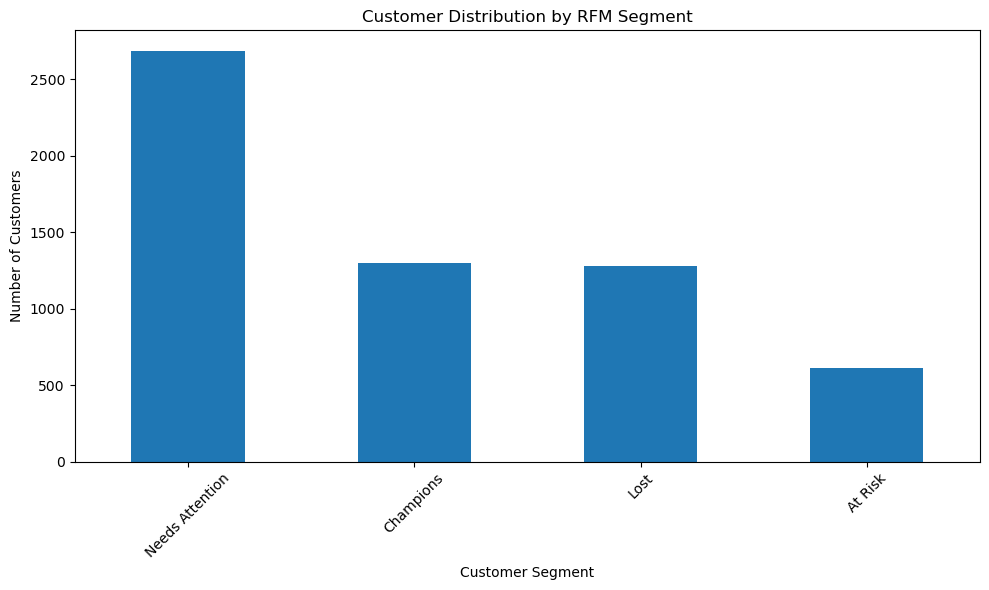

In [58]:
plt.figure(figsize=(10,6))

segment_counts.plot(kind='bar')

plt.title('Customer Distribution by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

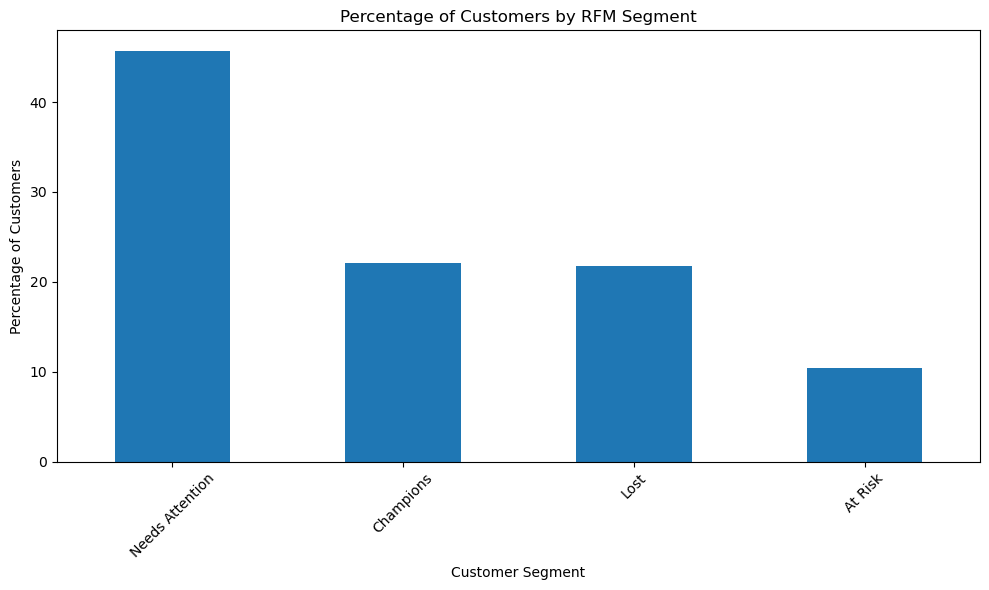

In [59]:
segment_percentage.plot( kind='bar',             # Customers Segment Percentage
     figsize=(10,6)
)

plt.title('Percentage of Customers by RFM Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [60]:
#Compare segment spending
segment_revenue = ( rfm.groupby('Segment')['Monetary'].sum()        
                    .sort_values(ascending=False)
                  )

segment_revenue

Segment
Champions          1.185959e+07
Needs Attention    3.686292e+06
At Risk            1.505647e+06
Lost               3.232743e+05
Name: Monetary, dtype: float64

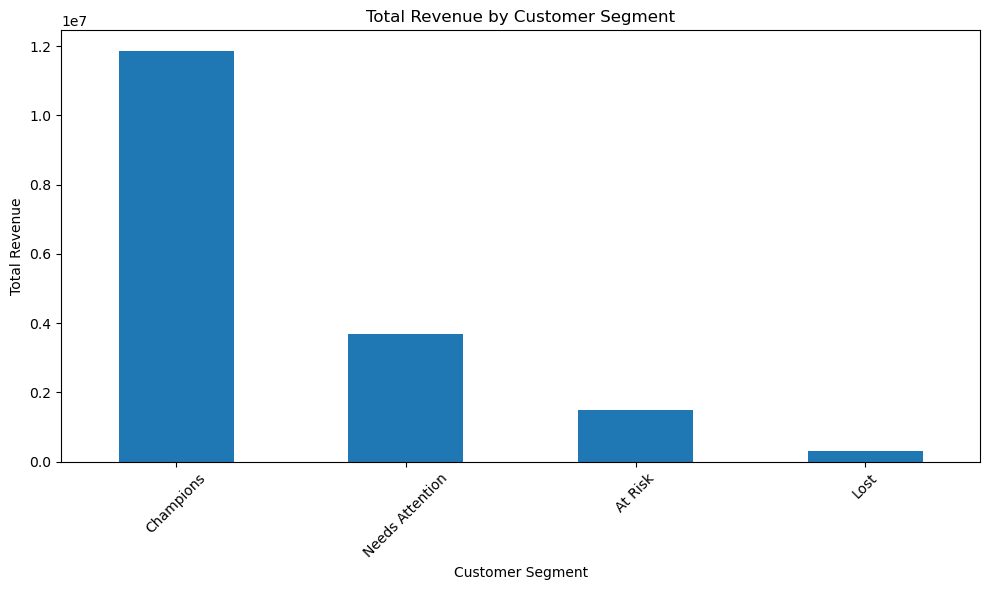

In [61]:
segment_revenue.plot( kind='bar',  
    figsize=(10,6)
)

plt.title('Total Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

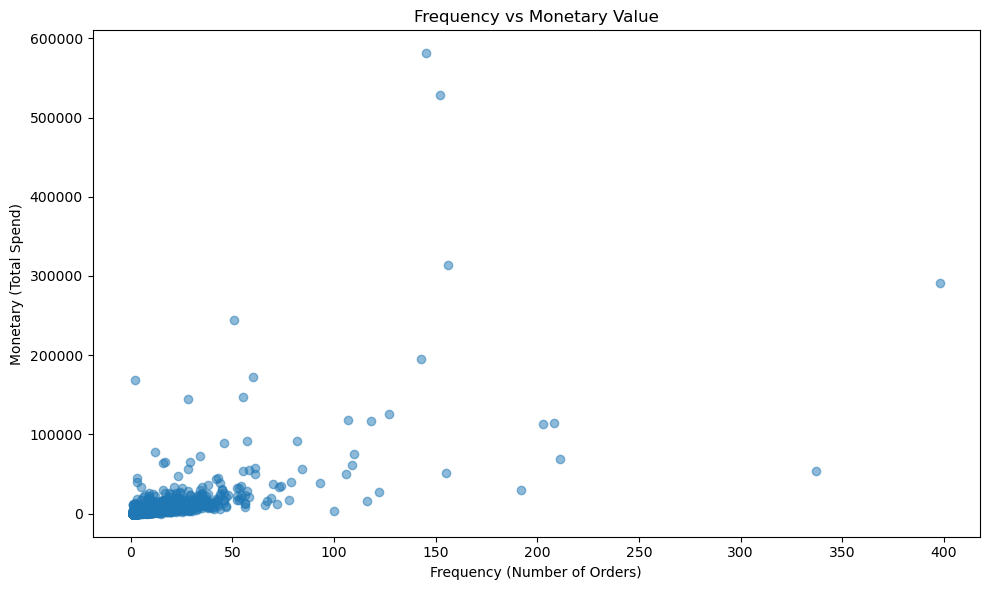

In [62]:
# Frequency vs Monetary
plt.figure(figsize=(10,6))

plt.scatter(rfm['Frequency'],rfm['Monetary'], alpha=0.5)

plt.title('Frequency vs Monetary Value')
plt.xlabel('Frequency (Number of Orders)')
plt.ylabel('Monetary (Total Spend)')
plt.tight_layout()
plt.show()

In [63]:
rfm.to_csv('customer_rfm.csv')                    # Save the RFM file for export

In [64]:
# Most valuable customers
top_customers = rfm.sort_values( 'Monetary',
                   ascending=False).head(10)

top_customers[['Recency','Frequency','Monetary','Segment']]

,Recency,Frequency,Monetary,Segment
Customer ID,,,,
18102.0,1,145,580987.04,Champions
14646.0,2,152,528602.52,Champions
14156.0,10,156,313437.62,Champions
14911.0,1,398,291420.81,Champions
17450.0,8,51,244784.25,Champions
13694.0,4,143,195640.69,Champions
17511.0,3,60,172132.87,Champions
16446.0,1,2,168472.50,Needs Attention
16684.0,4,55,147142.77,Champions


In [65]:
rfm.head(10)

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2,5,5,12,At Risk
12347.0,2,8,4921.53,5,4,5,14,Champions
12348.0,75,5,2019.40,3,4,4,11,Needs Attention
12349.0,19,4,4428.69,5,3,5,13,Needs Attention
12350.0,310,1,334.40,2,1,2,5,Lost
12351.0,375,1,300.93,2,1,2,5,Lost
12352.0,36,10,2849.84,4,5,4,13,Champions
12353.0,204,2,406.76,2,2,2,6,Lost
12354.0,232,1,1079.40,2,1,3,6,Needs Attention


In [66]:
# RFM Table
rfm.to_csv('RFM_Customer_Segmentation.csv',
index=True)

In [67]:
rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Total,Segment
Customer ID,,,,,,,,
12346.0,326,12,77556.46,2,5,5,12,At Risk
12347.0,2,8,4921.53,5,4,5,14,Champions
12348.0,75,5,2019.40,3,4,4,11,Needs Attention
12349.0,19,4,4428.69,5,3,5,13,Needs Attention
12350.0,310,1,334.40,2,1,2,5,Lost
